# Wrapper Methods: Sequential Feature Selection (SFS & SBS)

### 1. Clear Overview
**Wrapper methods** perform feature selection by treating the machine learning model as a "black box" and evaluating different feature subsets based on their predictive performance. 

Unlike Filter methods (which rely on independent statistical scores like Pearson or Chi-Square), Wrapper methods incorporate the model’s actual performance (e.g., cross-validated accuracy) into the selection process, making them highly effective but computationally demanding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split, cross_val_score

sns.set_theme(style="whitegrid")

### 2. Generating Synthetic Data
To test our wrappers, we will generate a dataset with **10 features** total:
* **3 Informative Features:** Actually drive the target variable.
* **2 Redundant Features:** Correlated with the informative features (we want to see if the wrapper drops them).
* **5 Noise Features:** Pure randomness.

In [2]:
X, y = make_classification(
    n_samples=1000, 
    n_features=10, 
    n_informative=3, 
    n_redundant=2, 
    n_repeated=0,
    random_state=42
)

feature_names = [f'Feature_{i}' for i in range(1, 11)]
df_X = pd.DataFrame(X, columns=feature_names)

print("Dataset Shape:", df_X.shape)
display(df_X.head())

Dataset Shape: (1000, 10)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,-1.408059,0.898360,1.577889,-1.499181,-0.323898,0.248532,-1.544936,-1.981964,1.124777,0.148810
1,1.136616,0.264290,-0.854044,0.855202,0.780613,0.788868,-1.525572,-1.154163,1.313782,0.326078
2,-0.990615,-0.265605,0.848414,-0.170258,0.594419,0.685745,-0.650660,-2.090303,-0.399878,0.573126
3,-1.194565,-0.181503,4.061466,-0.995148,-1.759389,1.854545,0.321679,0.168060,-2.177065,-0.140595
4,2.917665,-0.630458,-3.711618,-0.380456,2.152247,0.438626,2.159121,0.091315,1.637082,0.542914


### 3. Baseline Model (All Features)
Before applying feature selection, let's establish a baseline performance using all 10 features.

In [3]:
# Define the base model
base_model = LogisticRegression(max_iter=1000, random_state=42)

# Evaluate baseline using 5-fold cross-validation
baseline_scores = cross_val_score(base_model, df_X, y, cv=5, scoring='accuracy')
baseline_acc = baseline_scores.mean()

print(f"Baseline Cross-Validated Accuracy (All 10 Features): {baseline_acc:.4f}")

Baseline Cross-Validated Accuracy (All 10 Features): 0.9060


### 4. Sequential Forward Selection (SFS)
**Strategy:** "Building up" (Starts with 0 features). 
Iteratively adds the single feature that provides the greatest boost to the model’s performance until it reaches the desired number of features (in this case, 4).

In [4]:
print("Running Sequential Forward Selection (SFS)...")
sfs = SequentialFeatureSelector(base_model, n_features_to_select=4, direction='forward', cv=3, n_jobs=-1)
sfs.fit(df_X, y)

# Get the boolean mask of selected features
sfs_support = sfs.get_support()
sfs_features = df_X.columns[sfs_support].tolist()

print(f"\nFeatures selected by SFS: {sfs_features}")

# Evaluate model using only SFS features
sfs_scores = cross_val_score(base_model, df_X[sfs_features], y, cv=5, scoring='accuracy')
sfs_acc = sfs_scores.mean()
print(f"SFS Cross-Validated Accuracy (4 Features): {sfs_acc:.4f}")

Running Sequential Forward Selection (SFS)...

Features selected by SFS: ['Feature_1', 'Feature_5', 'Feature_6', 'Feature_9']
SFS Cross-Validated Accuracy (4 Features): 0.9110


### 5. Sequential Backward Selection (SBS)
**Strategy:** "Pruning down" (Starts with all features).
Iteratively removes the feature whose removal causes the least harm to model performance until it reaches the desired number of features.

In [5]:
print("Running Sequential Backward Selection (SBS)...")
sbs = SequentialFeatureSelector(base_model, n_features_to_select=4, direction='backward', cv=3, n_jobs=-1)
sbs.fit(df_X, y)

# Get the boolean mask of selected features
sbs_support = sbs.get_support()
sbs_features = df_X.columns[sbs_support].tolist()

print(f"\nFeatures selected by SBS: {sbs_features}")

# Evaluate model using only SBS features
sbs_scores = cross_val_score(base_model, df_X[sbs_features], y, cv=5, scoring='accuracy')
sbs_acc = sbs_scores.mean()
print(f"SBS Cross-Validated Accuracy (4 Features): {sbs_acc:.4f}")

Running Sequential Backward Selection (SBS)...

Features selected by SBS: ['Feature_1', 'Feature_5', 'Feature_8', 'Feature_10']
SBS Cross-Validated Accuracy (4 Features): 0.9070


### 6. Comparison and Trade-offs
Let's visualize the results. Because SFS starts from empty and builds up, while SBS starts full and prunes down, they can sometimes arrive at slightly different "optimal" subsets due to their greedy nature.

C:\Users\balasubramanian.pg\AppData\Local\Temp\ipykernel_12436\399917574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Accuracy', data=results, palette='mako')


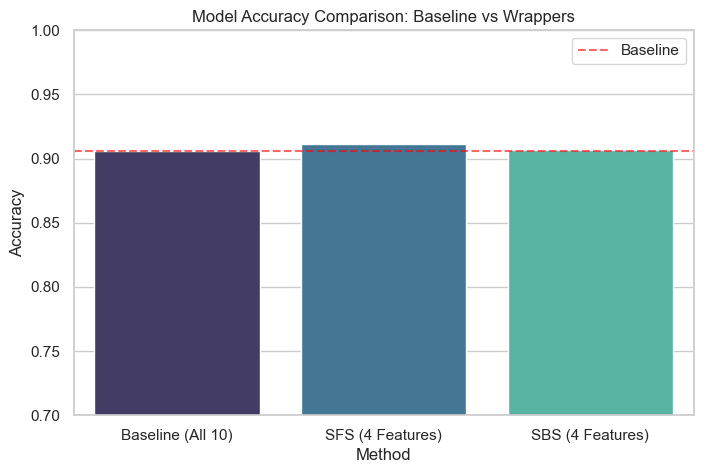

--- Actionable Insights ---
1. Dimensionality Reduction: We removed 60% of our features (10 down to 4) while maintaining (or even improving) accuracy. This prevents overfitting and speeds up inference.
2. The Greedy Trap: If SFS and SBS picked different features, it's because they make the 'locally best' choice at each step. SFS might miss complex multi-feature interactions that SBS catches (since SBS evaluates features in the presence of all others).
3. Computational Cost: Notice how long the cells took to run compared to Filter methods. For huge datasets with 1000s of features, SFS/SBS become computationally unfeasible.


In [6]:
results = pd.DataFrame({
    'Method': ['Baseline (All 10)', 'SFS (4 Features)', 'SBS (4 Features)'],
    'Accuracy': [baseline_acc, sfs_acc, sbs_acc]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Method', y='Accuracy', data=results, palette='mako')
plt.ylim(0.7, 1.0) # Zoom in for clarity
plt.title("Model Accuracy Comparison: Baseline vs Wrappers")
plt.axhline(baseline_acc, color='red', linestyle='--', alpha=0.6, label='Baseline')
plt.legend()
plt.show()

print("--- Actionable Insights ---")
print("1. Dimensionality Reduction: We removed 60% of our features (10 down to 4) while maintaining (or even improving) accuracy. This prevents overfitting and speeds up inference.")
print("2. The Greedy Trap: If SFS and SBS picked different features, it's because they make the 'locally best' choice at each step. SFS might miss complex multi-feature interactions that SBS catches (since SBS evaluates features in the presence of all others).")
print("3. Computational Cost: Notice how long the cells took to run compared to Filter methods. For huge datasets with 1000s of features, SFS/SBS become computationally unfeasible.")